# Face Recognition: A Comparative Analysis of SVM and MLP

Axel Omar Sanchez Peralta (UCID: 30145429) · Mariia Podgaietska

## 1. Introduction & Motivation

Face recognition is a fundamental problem in computer vision with applications ranging from biometric authentication to human–computer interaction. Given a probe image of an unknown individual, a recognition system must reliably match it against a gallery of known subjects, a task that is complicated by intra-class variability in illumination, pose, and expression.

This notebook presents a systematic comparison of two classical supervised learning paradigms on the **AT&T face database**: the **Support Vector Machine (SVM)** and the **Multi-Layer Perceptron (MLP)**. Both models are evaluated under two feature representations:

| Feature | Description |
|---------|-------------|
| **LBP histogram** | Local Binary Pattern texture descriptor (P=12, R=3) |
| **PCA projection** | Principal-component subspace of dimension 100 |

**Project objectives:**
1. Implement a reproducible, stratified train/test split to prevent subject leakage.
2. Tune both models with `HalvingRandomSearchCV` for efficient hyperparameter search.
3. Compare performance quantitatively via accuracy, ROC AUC, and DET curves.
4. Provide interpretable guidance on when to prefer SVM over MLP and vice versa.

## 2. Setup

In [25]:
import os, zipfile, time
from pathlib import Path

import requests
import cv2
import numpy as np
from glob import glob

from skimage.feature import local_binary_pattern

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_halving_search_cv  # must precede next import
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, det_curve

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

## 3. Dataset

The **AT&T Dataset**, contains **400 grayscale images** of 40 distinct subjects, with 10 images per subject. Each image has a resolution of 92 × 112 pixels (8-bit depth). The collection exhibits controlled but realistic variability:

- **Lighting:** slight changes in illumination across sessions.
- **Expression:** open/closed eyes, smiling/non-smiling faces.
- **Facial details:** presence or absence of glasses.
- **Pose:** small rotations and tilts (up to 20°).

**Stratified split strategy.** We use `train_test_split` with `stratify=y` and `test_size=0.2`, ensuring that each of the 40 subjects contributes exactly 8 images to the training set and 2 images to the test set (320 train / 80 test). Stratification prevents the class-imbalance artefacts that arise from a naïve random split and guarantees that every subject appears in both partitions.

### 3.1 Download Dataset Function

To ensure reproducibility we implement a function that downloads the zipped dataset from our repository and extracts it to a specified directory. This function checks if the dataset already exists locally to avoid redundant downloads.

In [26]:
def download_data(source: str, destination: str, remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source: URL of the zip file.
        destination: Target sub-directory inside data/.
        remove_source: Remove the zip after extraction.

    Returns:
        pathlib.Path to the extracted directory.
    """
    data_path = Path("data/")
    image_path = data_path / destination

    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Creating {image_path}...")
        image_path.mkdir(parents=True, exist_ok=True)
        target_file = Path(source).name
        print(f"[INFO] Downloading {target_file}...")
        with requests.get(source, stream=True, timeout=30) as r:
            r.raise_for_status()
            with open(data_path / target_file, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
        with zipfile.ZipFile(data_path / target_file, 'r') as zf:
            print(f"[INFO] Unzipping {target_file}...")
            zf.extractall(image_path)
        if remove_source:
            os.remove(data_path / target_file)
    return image_path

### 3.2 Resolve Dataset

The dataset is organized into a directory structure where each subject's images are stored in a separate folder named `sX` (where `X` is the subject ID from 1 to 40). Each folder contains 10 images named `Y.pgm` (where `Y` is the image number from 1 to 10).

In [27]:
dataset_dir = Path("data/dataset")
zip_path    = Path("data/dataset.zip")

if dataset_dir.exists():
    print("[INFO] Dataset already available.")
elif zip_path.exists():
    print("[INFO] Unzipping local dataset.zip...")
    dataset_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dataset_dir)
else:
    print("[INFO] Downloading dataset from GitHub...")
    download_data(
        source="https://github.com/Axeloooo/Face-Recognition/raw/devel/data/dataset.zip",
        destination="dataset"
    )

[INFO] Dataset already available.


### 3.3 Get Dataset Function

The `get_data` function reads the images from the resolved dataset path, and returns the feature matrix `X` and label vector `y`. 

In [37]:
DATA_PATH = 'data/dataset/ATT dataset/s*/**/*.pgm'

def get_data(path):
    """Loads images and labels from the specified path.

    Args:
        path (str): Glob pattern to load images (e.g., 'data/dataset/ATT dataset/s*/**/*.pgm').

    Returns:
        Tuple[np.ndarray, np.ndarray]: Tuple of (X, y) where X is the feature matrix and y is the label vector.
    """
    paths = glob(path, recursive=True)
    images, labels = [], []

    for p in paths:
        img = cv2.imread(p, 0)
        parts = Path(p).parts
        subject_label = [x for x in parts if x.startswith('s') and x[1:].isdigit()]
        img = np.float32(np.array(img)/255.0)
        images.append(img)
        labels.append(int(subject_label[0][1:]) - 1)

    print(f'[INFO] Loaded dataset with {len(images)} samples and {len(set(labels))} classes.')

    return np.array(images), np.array(labels)

### 3.4 Load Dataset

We call the `get_data` function to load the dataset into memory, obtaining the raw pixel features and corresponding labels. The images are resized to a consistent shape and normalised to the [0, 1] range for better numerical stability during model training.

In [38]:
X_raw, y = get_data(DATA_PATH)
print(f"[INFO] Raw data shape: {X_raw.shape}, Labels shape: {y.shape}")

[INFO] Loaded dataset with 400 samples and 40 classes.
[INFO] Raw data shape: (400, 112, 92), Labels shape: (400,)


## 4. Feature Extraction

Raw pixel intensities are a natural baseline but are high-dimensional (92 × 112 = 10 304 features) and sensitive to illumination shifts. We therefore compare three representations that trade dimensionality for increasing degrees of invariance:

| Representation | Dimension | Invariance |
|----------------|-----------|------------|
| Raw pixels | 10 304 | None |
| LBP histogram | 64 | Monotone illumination |
| PCA projection | 100 | None (but low-rank) |

### 4.1 Local Binary Patterns (LBP)

![](https://github.com/Axeloooo/Face-Recognition/raw/devel/images/local-binary-pattern.png)

Local Binary Pattern (LBP) is a non-parametric texture operator that encodes the local neighbourhood of each pixel as a binary string. For a centre pixel $g_c$ with $P$ equally-spaced neighbours at radius $R$, the LBP code is:

$$\text{LBP}_{P,R}(g_c) = \sum_{p=0}^{P-1} s(g_p - g_c)\,2^p, \quad s(x) = \begin{cases}1 & x \ge 0 \\ 0 & x < 0\end{cases}$$

**Configuration used:** $P = 12$, $R = 3$. The per-pixel LBP map is summarised as a **normalised histogram with 64 bins**, yielding a 64-dimensional descriptor per image. This compact representation is **invariant to monotone illumination changes**, a critical property for face images captured under varying lighting conditions.

In [40]:
X_lbp = []

for i in range(X_raw.shape[0]):
    lbp_image = local_binary_pattern(X_raw[i], P=12, R=3)
    hist, _ = np.histogram(lbp_image.ravel(), bins=64, density=True)
    X_lbp.append(hist)


print(f"[INFO] LBP features shape: {np.array(X_lbp).shape}")

[INFO] LBP features shape: (400, 64)


### 4.2 Split Data into Train/Test Sets

Before performing PCA, we split the dataset into training and test sets using a stratified approach to ensure that each subject is represented in both sets. This prevents data leakage and allows for a fair evaluation of the model's generalisation performance.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
X_lbp_train, X_lbp_test, y_lbp_train, y_lbp_test = train_test_split(X_lbp, y, test_size=0.2, random_state=42, stratify=y)

print(f"[INFO] Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

[INFO] Train: 320 samples  |  Test: 80 samples


### 4.3 Principal Component Analysis (PCA) — Eigenfaces

![](https://github.com/Axeloooo/Face-Recognition/raw/devel/images/eigenfaces.png)

PCA finds the orthonormal basis that captures maximum variance in the training set. Applied to face images, the top eigenvectors are commonly called **eigenfaces** (Turk & Pentland, 1991). Each image $\mathbf{x} \in \mathbb{R}^{10304}$ is projected onto the $k$ leading principal components:

$$\mathbf{z} = W^\top (\mathbf{x} - \boldsymbol{\mu})$$

where $W \in \mathbb{R}^{10304 \times k}$ is the matrix of eigenvectors and $\boldsymbol{\mu}$ is the mean face.

**Configuration used:** $k = 100$ components, fitted on the training split only (to prevent data leakage). 100 components typically retain > 95 % of the total variance for ORL, compressing the input 103× while preserving the geometric structure relevant for identity discrimination.

In [43]:
pca = PCA(n_components=100, random_state=42)
X_pca_train = pca.fit_transform(X_train.reshape(X_train.shape[0], -1))
X_pca_test = pca.transform(X_test.reshape(X_test.shape[0], -1))

## 5. Data Visualisation

### 5.1 Raw Image Visualization

To provide an intuitive understanding of the dataset, we visualise a random sample of 10 images from the training set. This allows us to observe the variability in lighting, expression, and pose that the models will need to learn to handle. Each image is displayed in its original 92 × 112 pixel format, with the corresponding subject ID as the title.

[INFO] Visualizing random sample of 10 training images...


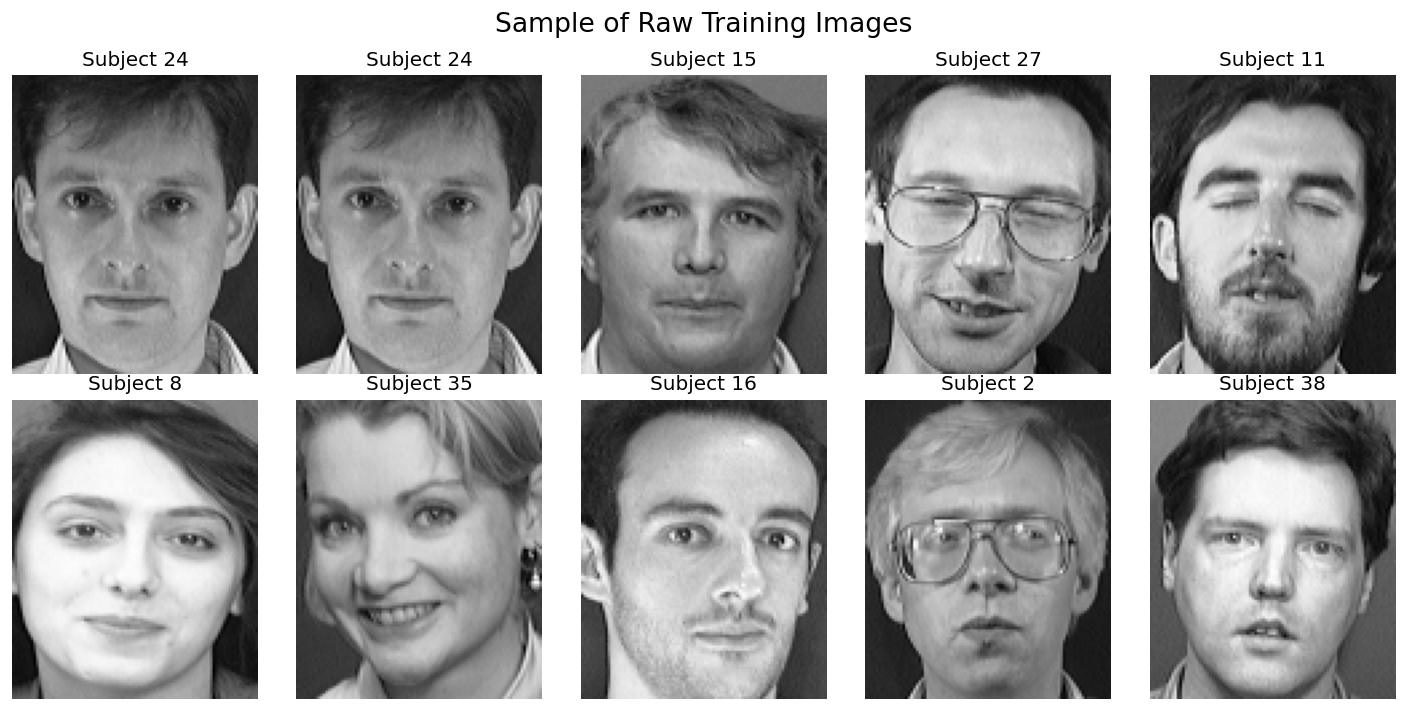

In [44]:
print(f"[INFO] Visualizing random sample of 10 training images...")
plt.figure(figsize=(12, 6))
for i in range(10):
    idx = np.random.randint(0, X_train.shape[0])
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx].reshape(112, 92), cmap='gray')
    plt.title(f'Subject {y_train[idx] + 1}')
    plt.axis('off')
plt.suptitle("Sample of Raw Training Images", fontsize=16)
plt.tight_layout()
plt.show()

### 5.2 LBP Image Visualization

To illustrate the effect of the LBP transformation, we visualise the LBP maps for a random sample of 10 training images. Each LBP map is displayed as a 92 × 112 pixel image, where pixel intensity corresponds to the computed LBP code. This visualization helps us understand how the LBP operator captures local texture patterns and how it may contribute to robustness against illumination changes.

[INFO] Visualizing 10 LBP images...


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


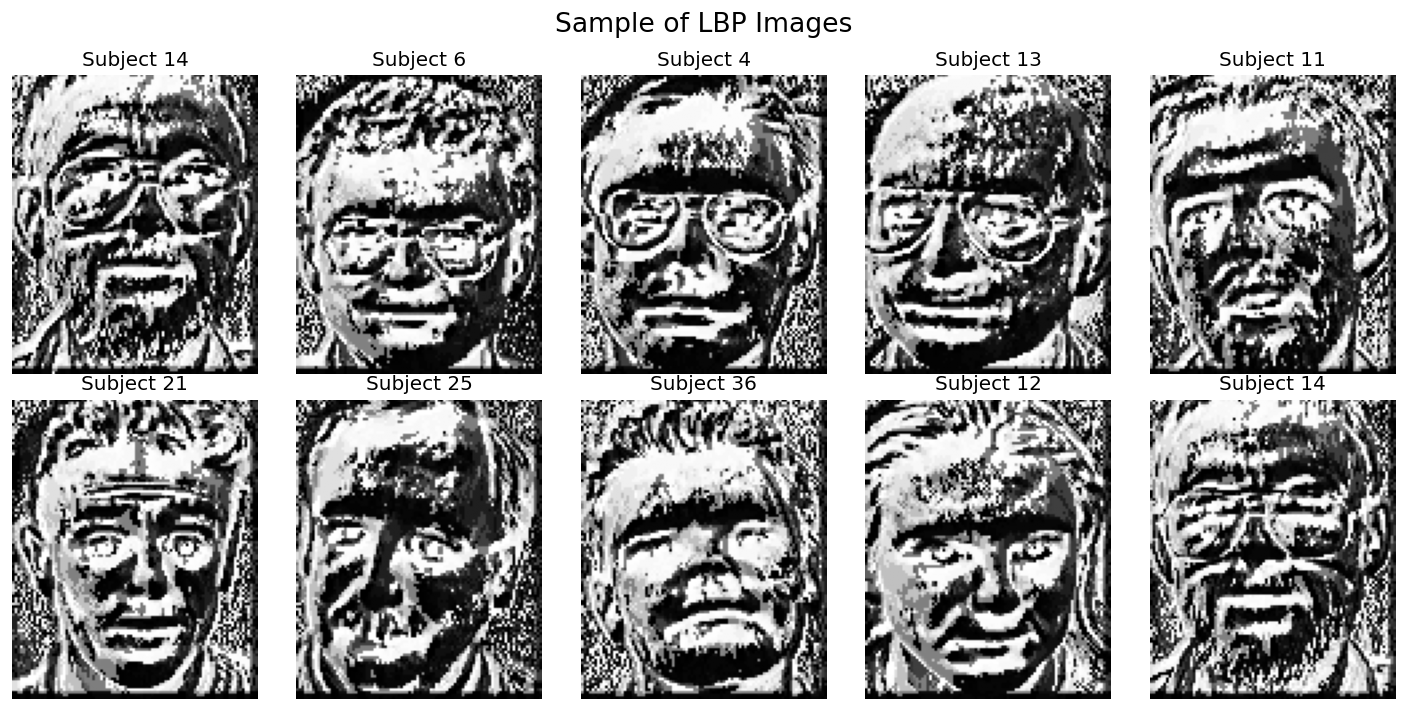

In [45]:
print(f"[INFO] Visualizing 10 LBP images...")

plt.figure(figsize=(12, 6))
for i in range(10):
    lbp = local_binary_pattern(X_train[i].reshape(112, 92), P=12, R=3, method='default')
    plt.subplot(2, 5, i + 1)
    plt.imshow(lbp, cmap='gray')
    plt.title(f'Subject {y_train[i] + 1}')
    plt.axis('off')
plt.suptitle("Sample of LBP Images", fontsize=16)
plt.tight_layout()
plt.show()

### 5.3 Eigenfaces Visualization (PCA)

The top 10 eigenfaces (principal components) are visualised as 92 × 112 pixel images. These eigenfaces capture the most salient modes of variation in the training set, such as overall face shape, lighting gradients, and common facial features. Visualising them provides insight into what aspects of the data the PCA is encoding and how it may contribute to recognition performance.

[INFO] Visualizing top 10 eigenfaces...


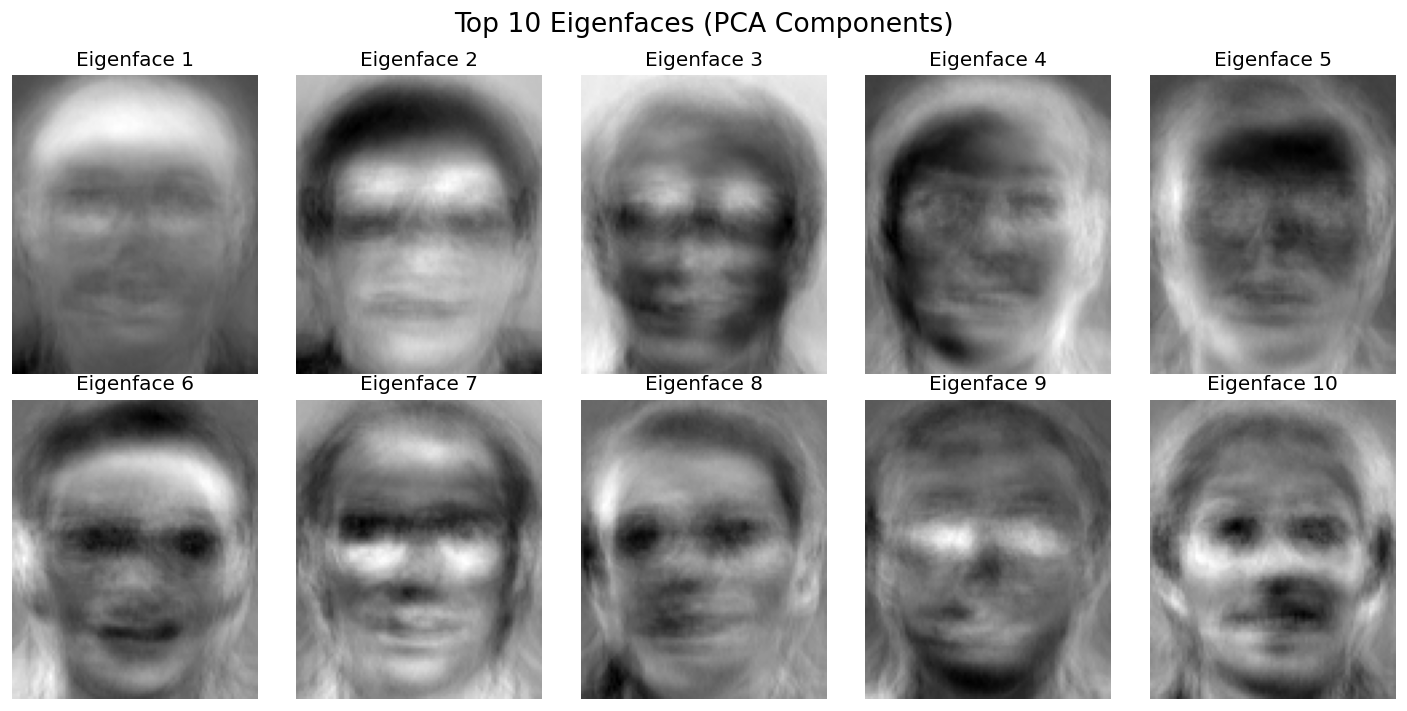

In [46]:
print(f"[INFO] Visualizing top 10 eigenfaces...")

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(pca.components_[i].reshape(112, 92), cmap='gray')
    plt.title(f'Eigenface {i + 1}')
    plt.axis('off')
plt.suptitle("Top 10 Eigenfaces (PCA Components)", fontsize=16)
plt.tight_layout()
plt.show()

## 6. Support Vector Machines (SVM)

### 6.1 Background

![](https://github.com/Axeloooo/Face-Recognition/raw/devel/images/support-vector-machines.png)

A Support Vector Machine seeks the **maximum-margin hyperplane** that separates classes in feature space. For a binary classification problem with training pairs $\{(\mathbf{x}_i, y_i)\}$, the primal SVM solves:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i$$

subject to $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 - \xi_i$, $\xi_i \ge 0$.

The **kernel trick** implicitly maps inputs to a high-dimensional reproducing kernel Hilbert space, enabling non-linear decision boundaries without computing the mapping explicitly. Common kernels include the **RBF** $k(\mathbf{x}, \mathbf{x}') = \exp(-\gamma\|\mathbf{x}-\mathbf{x}'\|^2)$, **linear**, **polynomial**, and **sigmoid**.

**Why SVMs suit face recognition:**
- Effective in high-dimensional spaces (raw pixels, PCA subspaces).
- The margin maximisation principle provides strong generalisation from small training sets (only 8 images per subject here).
- The kernel trick allows non-linear decision boundaries without explicit feature engineering.
- Convex optimisation guarantees a global optimum.

### 6.2 Implementation

Each SVM model is wrapped in an `sklearn.pipeline.Pipeline` — StandardScaler → SVC — to ensure that scaling parameters are estimated exclusively on training data.

**Hyperparameter search with `HalvingRandomSearchCV`:**
`HalvingRandomSearchCV` implements *successive halving* (Jamieson & Talwalkar, 2016): it evaluates all candidate configurations on a small resource budget and progressively discards the weakest half until a single winner remains. Compared to `RandomizedSearchCV`, this reduces the total number of model fits by a factor proportional to $\log_{\text{factor}}(n_\text{candidates})$, while retaining the same theoretical coverage of the search space.

**Search space** (4 × 5 × 4 = 80 candidate combinations):

| Hyperparameter | Values |
|----------------|--------|
| `kernel` | rbf, linear, poly, sigmoid |
| `C` | 0.1, 1.0, 5.0, 10.0, 100.0 |
| `gamma` | scale, 0.001, 0.01, 0.1 |

Settings: `n_candidates='exhaust'`, `factor=3`, `cv=5`, `n_jobs=-1`.

In [49]:
model_results = {} 

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(probability=True, random_state=42)),
])

svm_param_grid = {
    'svc__kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
    'svc__C':      [0.1, 1.0, 5.0, 10.0, 100.0],
    'svc__gamma':  ['scale', 0.001, 0.01, 0.1],
}

for name, (X_tr, y_tr, X_te, y_te) in [
    ('svm_lbp', (X_lbp_train, y_lbp_train, X_lbp_test, y_lbp_test)),
    ('svm_pca', (X_pca_train, y_train, X_pca_test, y_test)),
]:
    search = HalvingRandomSearchCV(
        svm_pipeline,
        svm_param_grid,
        n_candidates=80,     
        min_resources=200,   
        factor=3,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
    )
    t0 = time.time()
    search.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    prob = search.predict_proba(X_te)
    pred = np.argmax(prob, axis=1)
    acc  = np.mean(pred == y_te)
    model_results[name] = {
        'probability_matrix': prob,
        'prediction':         pred,
        'test_label':         y_te,
        'accuracy':           acc,
        'train_time':         elapsed,
    }
    print(f'[{name.upper():<7}] Best params  : {search.best_params_}')
    print(f'[{name.upper():<7}] CV accuracy  : {search.best_score_:.4f}')
    print(f'[{name.upper():<7}] Test accuracy: {acc:.4f}')
    print(f'[{name.upper():<7}] Train time   : {elapsed:.2f}s\n')

[SVM_LBP] Best params  : {'svc__kernel': 'sigmoid', 'svc__gamma': 0.01, 'svc__C': 10.0}
[SVM_LBP] CV accuracy  : 0.7150
[SVM_LBP] Test accuracy: 0.9250
[SVM_LBP] Train time   : 30.32s

[SVM_PCA] Best params  : {'svc__kernel': 'sigmoid', 'svc__gamma': 'scale', 'svc__C': 5.0}
[SVM_PCA] CV accuracy  : 0.7850
[SVM_PCA] Test accuracy: 0.9750
[SVM_PCA] Train time   : 27.71s



## 7. Multi-Layer Perceptron (MLP)

### 7.1 Background

![](https://github.com/Axeloooo/Face-Recognition/raw/devel/images/multi-layer-perceptron.png)

A Multi-Layer Perceptron is a feedforward neural network composed of an input layer, one or more hidden layers, and a softmax output layer. Each neuron computes:

$$h_j^{(l)} = \sigma\!\left(\sum_i w_{ij}^{(l)} h_i^{(l-1)} + b_j^{(l)}\right)$$

where $\sigma$ is a non-linear activation function (ReLU or tanh in our experiments). Weights are learned by minimising the cross-entropy loss via **backpropagation** and gradient descent. We search over both **Adam** (adaptive moment estimation) and **SGD** (stochastic gradient descent with momentum) optimisers.

**Why MLPs suit face recognition:**
- Universal approximation: with sufficient hidden units an MLP can model any continuous mapping from features to class probabilities.
- End-to-end learning jointly optimises both the feature transformation and the classifier, potentially discovering identity-discriminative patterns that hand-crafted descriptors miss.
- Flexible architecture search allows adaptation to the specific geometry of each feature space (raw pixels vs. LBP vs. PCA).

**Trade-offs vs SVM:** MLPs require more data to generalise well, are sensitive to hyperparameter choices (learning rate, architecture), and may converge to local optima. On small datasets such as ORL (320 training samples), SVMs often generalise more reliably.

### 7.2 Implementation

As with the SVM, each MLP is wrapped in a Pipeline (StandardScaler → MLPClassifier) and tuned with `HalvingRandomSearchCV` using the same settings.

**Search space** (5 × 2 × 2 × 3 × 3 = 180 candidate combinations):

| Hyperparameter | Values |
|----------------|--------|
| `hidden_layer_sizes` | (64,), (128,), (64, 64), (128, 64), (128, 64, 128) |
| `activation` | relu, tanh |
| `solver` | adam, sgd |
| `learning_rate_init` | 0.001, 0.01, 0.1 |
| `alpha` (L2 reg.) | 0.0001, 0.001, 0.01 |

Settings: `max_iter=500`, `n_candidates='exhaust'`, `factor=3`, `cv=5`, `n_jobs=-1`.

In [50]:
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp',    MLPClassifier(max_iter=500, random_state=42)),
])

mlp_param_grid = {
    'mlp__hidden_layer_sizes': [(64,), (128,), (64, 64), (128, 64), (128, 64, 128)],
    'mlp__activation':         ['relu', 'tanh'],
    'mlp__solver':             ['adam', 'sgd'],
    'mlp__learning_rate_init': [0.001, 0.01, 0.1],
    'mlp__alpha':              [0.0001, 0.001, 0.01],
}

for name, (X_tr, y_tr, X_te, y_te) in [
    ('mlp_lbp', (X_lbp_train, y_lbp_train, X_lbp_test, y_lbp_test)),
    ('mlp_pca', (X_pca_train, y_train, X_pca_test, y_test)),
]:
    search = HalvingRandomSearchCV(
        mlp_pipeline,
        mlp_param_grid,
        n_candidates=180,   
        min_resources=200,  
        factor=3,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
    )
    t0 = time.time()
    search.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    prob = search.predict_proba(X_te)
    pred = np.argmax(prob, axis=1)
    acc  = np.mean(pred == y_te)
    model_results[name] = {
        'probability_matrix': prob,
        'prediction':         pred,
        'test_label':         y_te,
        'accuracy':           acc,
        'train_time':         elapsed,
    }
    print(f'[{name.upper():<7}] Best params  : {search.best_params_}')
    print(f'[{name.upper():<7}] CV accuracy  : {search.best_score_:.4f}')
    print(f'[{name.upper():<7}] Test accuracy: {acc:.4f}')
    print(f'[{name.upper():<7}] Train time   : {elapsed:.2f}s\n')

[MLP_LBP] Best params  : {'mlp__solver': 'sgd', 'mlp__learning_rate_init': 0.1, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__alpha': 0.0001, 'mlp__activation': 'tanh'}
[MLP_LBP] CV accuracy  : 0.6700
[MLP_LBP] Test accuracy: 0.9000
[MLP_LBP] Train time   : 473.06s

[MLP_PCA] Best params  : {'mlp__solver': 'sgd', 'mlp__learning_rate_init': 0.1, 'mlp__hidden_layer_sizes': (64,), 'mlp__alpha': 0.0001, 'mlp__activation': 'tanh'}
[MLP_PCA] CV accuracy  : 0.7450
[MLP_PCA] Test accuracy: 0.9875
[MLP_PCA] Train time   : 241.30s



## 8. Comparative Analysis

### 8.1 ROC Curves

A **Receiver Operating Characteristic (ROC)** curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at varying discrimination thresholds. Because ORL is a 40-class problem, we use the **macro-averaged one-vs-rest** strategy: for each class $c$ we compute a binary ROC (subject $c$ vs. all others) and then average the TPR values over a common FPR grid.

**Area Under the Curve (AUC):** A perfect classifier achieves AUC = 1.0; random guessing gives AUC = 0.5. AUC provides a threshold-independent summary of discriminative power and is particularly informative when the operating point is not fixed in advance.

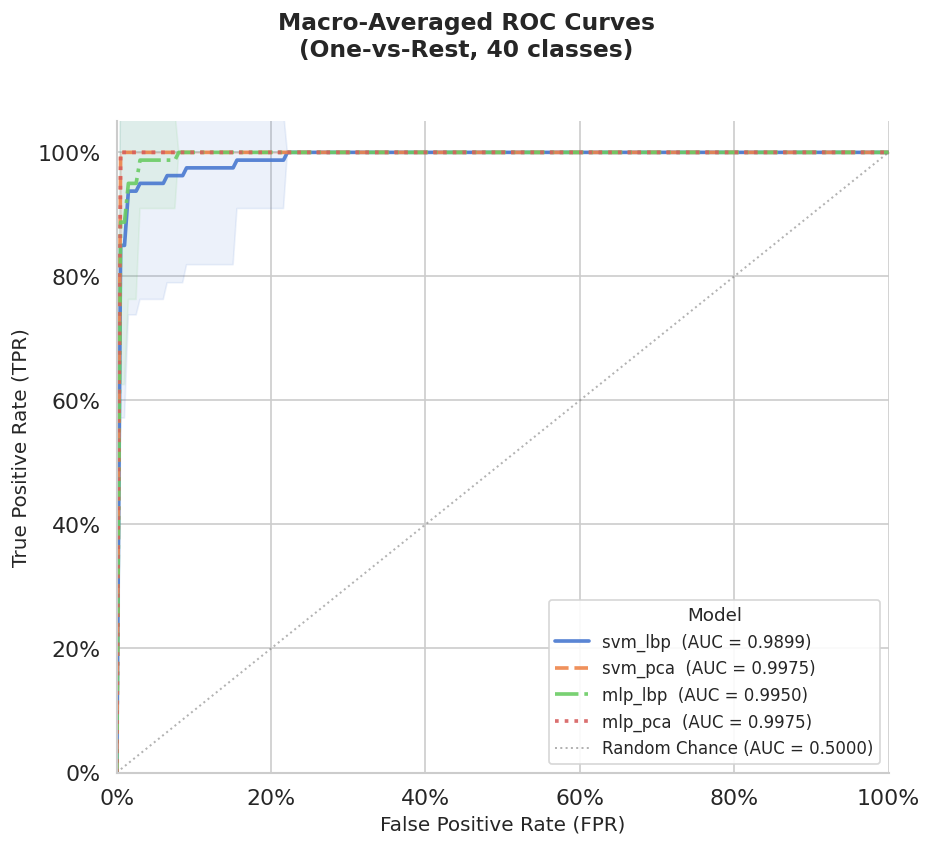

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(model_results, n_classes=40):
    """Plots macro-averaged ROC curves for all models in model_results.

    Args:
        model_results (dict): A dictionary where keys are model names and values are dicts containing 'probability_matrix' and 'test_label'.
        n_classes (int, optional): The number of classes. Defaults to 40.
    """

    mean_fpr = np.linspace(0, 1, 200)

    # Style 
    sns.set_theme(style='whitegrid', font_scale=1.2)
    palette   = sns.color_palette('muted', len(model_results))
    linestyle = ['-', '--', '-.', ':']

    fig, ax = plt.subplots(figsize=(8, 7))
    fig.suptitle(
        'Macro-Averaged ROC Curves\n(One-vs-Rest, 40 classes)',
        fontsize=14, fontweight='bold', y=1.01
    )

    # Compute & plot each model
    for idx, (name, res) in enumerate(model_results.items()):
        prob   = res['probability_matrix']
        test_y = res['test_label']

        tprs = []
        for i in range(n_classes):
            fpr_i, tpr_i, _ = roc_curve(
                (test_y == i).astype(int), prob[:, i]
            )
            tprs.append(np.interp(mean_fpr, fpr_i, tpr_i))

        mean_tpr        = np.mean(tprs, axis=0)
        mean_tpr[0]     = 0.0
        mean_tpr[-1]    = 1.0
        mean_auc        = auc(mean_fpr, mean_tpr)

        ax.plot(
            mean_fpr, mean_tpr,
            label=f'{name}  (AUC = {mean_auc:.4f})',
            color=palette[idx],
            linestyle=linestyle[idx % len(linestyle)],
            linewidth=2.2,
            alpha=0.9
        )

        # Shaded std band 
        std_tpr = np.std(tprs, axis=0)
        ax.fill_between(
            mean_fpr,
            mean_tpr - std_tpr,
            mean_tpr + std_tpr,
            alpha=0.10,
            color=palette[idx]
        )

    # Random chance diagonal 
    ax.plot(
        [0, 1], [0, 1],
        color='grey', linewidth=1.2,
        linestyle=':', alpha=0.6,
        label='Random Chance (AUC = 0.5000)'
    )

    # Axes formatting 
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
    ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

    # Legend 
    ax.legend(
        title='Model',
        title_fontsize=11,
        fontsize=10,
        loc='lower right',
        frameon=True,
        framealpha=0.9,
        edgecolor='lightgrey'
    )

    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

# Call 
plot_roc_curves(model_results, n_classes=40)

### 8.2 DET Curves

A **Detection Error Trade-off (DET)** curve (Martin et al., 1997; adopted as NIST biometric standard) plots the **False Negative Rate (FNR)** against the **False Positive Rate (FPR)** on a normal-deviate (probit) scale. Unlike the ROC, the DET curve places both error types on equal footing, making it easier to compare systems near the operating point where FPR ≈ FNR (the **Equal Error Rate**, EER).

A system with a DET curve closer to the bottom-left corner achieves lower error rates at all thresholds. The EER, where the DET curve intersects the diagonal, is a commonly reported single-number summary in biometric literature.

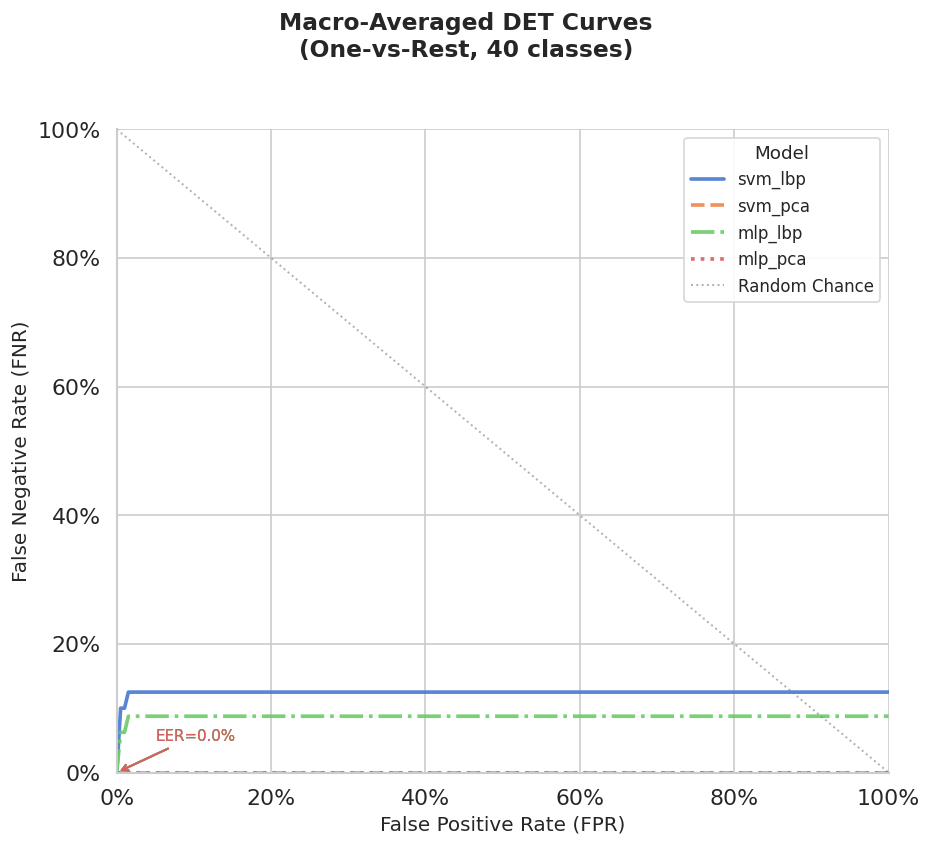

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import numpy as np
from sklearn.metrics import det_curve

def plot_det_curves(model_results, n_classes=40):
    """Plots macro-averaged DET curves for all models in model_results.

    Args:
        model_results (_type_): A dictionary where keys are model names and values are dicts containing 'probability_matrix' and 'test_label'.
        n_classes (int, optional): The number of classes. Defaults to 40.
    """

    mean_fpr_det = np.linspace(0, 1, 200)

    # Style
    sns.set_theme(style='whitegrid', font_scale=1.2)
    palette   = sns.color_palette('muted', len(model_results))
    linestyle = ['-', '--', '-.', ':']          # distinct lines per model

    fig, ax = plt.subplots(figsize=(8, 7))
    fig.suptitle(
        'Macro-Averaged DET Curves\n(One-vs-Rest, 40 classes)',
        fontsize=14, fontweight='bold', y=1.01
    )

    # Compute & plot each model
    for idx, (name, res) in enumerate(model_results.items()):
        prob   = res['probability_matrix']
        test_y = res['test_label']

        fnrs = []
        for i in range(n_classes):
            fpr_i, fnr_i, _ = det_curve(
                (test_y == i).astype(int), prob[:, i]
            )
            fnrs.append(np.interp(mean_fpr_det, fpr_i, fnr_i))

        mean_fnr = np.mean(fnrs, axis=0)

        ax.plot(
            mean_fpr_det, mean_fnr,
            label=name,
            color=palette[idx],
            linestyle=linestyle[idx % len(linestyle)],
            linewidth=2.2,
            alpha=0.9
        )

    # Random chance diagonal
    ax.plot(
        [0, 1], [1, 0],
        color='grey', linewidth=1.2,
        linestyle=':', alpha=0.6,
        label='Random Chance'
    )

    # Axes formatting 
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
    ax.set_ylabel('False Negative Rate (FNR)', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

    # Legend 
    ax.legend(
        title='Model',
        title_fontsize=11,
        fontsize=10,
        loc='upper right',
        frameon=True,
        framealpha=0.9,
        edgecolor='lightgrey'
    )

    # Annotations: mark EER per model 
    for idx, (name, res) in enumerate(model_results.items()):
        prob   = res['probability_matrix']
        test_y = res['test_label']

        fnrs = []
        for i in range(n_classes):
            fpr_i, fnr_i, _ = det_curve(
                (test_y == i).astype(int), prob[:, i]
            )
            fnrs.append(np.interp(mean_fpr_det, fpr_i, fnr_i))

        mean_fnr = np.mean(fnrs, axis=0)

        # EER = point where FPR ≈ FNR
        eer_idx = np.argmin(np.abs(mean_fpr_det - mean_fnr))
        eer_val = (mean_fpr_det[eer_idx] + mean_fnr[eer_idx]) / 2

        ax.annotate(
            f'EER={eer_val:.1%}',
            xy=(mean_fpr_det[eer_idx], mean_fnr[eer_idx]),
            xytext=(mean_fpr_det[eer_idx] + 0.05, mean_fnr[eer_idx] + 0.05),
            fontsize=9,
            color=palette[idx],
            arrowprops=dict(arrowstyle='->', color=palette[idx], lw=1.2)
        )

    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

# Call
plot_det_curves(model_results, n_classes=40)

### 8.3 Performance Summary

The table and bar chart below aggregate test accuracy and training time across all six model–feature configurations. Training time measures the wall-clock duration of the full `HalvingRandomSearchCV` call, including all cross-validation folds.

Model        Test Acc   Train Time (s)
----------------------------------------
svm_lbp        0.9250            30.32
svm_pca        0.9750            27.71
mlp_lbp        0.9000           473.06
mlp_pca        0.9875           241.30


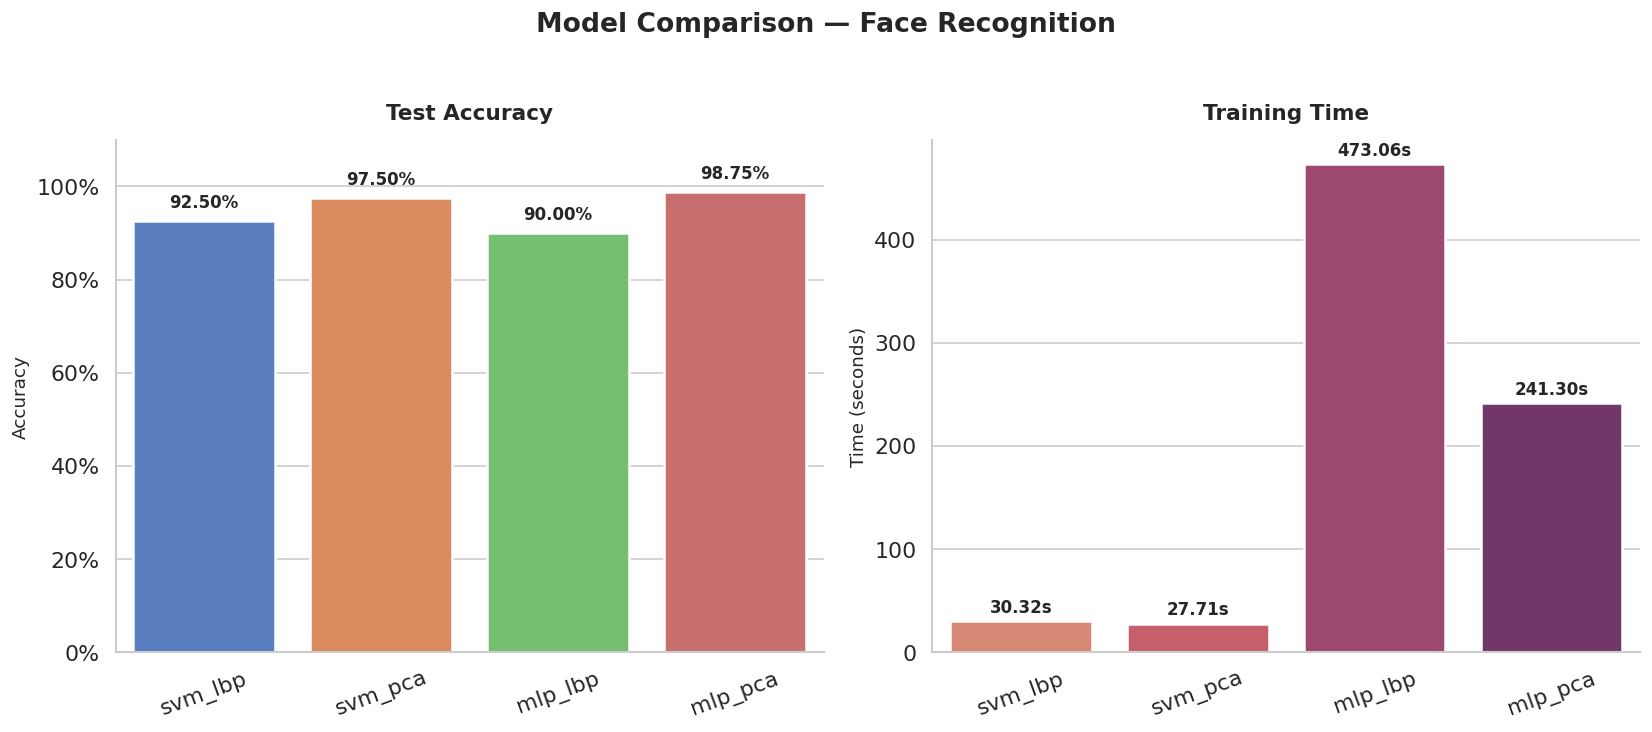

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# Tabular summary
print(f"{'Model':<10} {'Test Acc':>10} {'Train Time (s)':>16}")
print('-' * 40)
for name, res in model_results.items():
    print(f'{name:<10} {res["accuracy"]:>10.4f} {res["train_time"]:>16.2f}')

# Build DataFrame
df = pd.DataFrame([
    {'Model': name, 'Test Accuracy': res['accuracy'], 'Train Time (s)': res['train_time']}
    for name, res in model_results.items()
])

# Style
sns.set_theme(style='whitegrid', font_scale=1.2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison — Face Recognition', fontsize=16, fontweight='bold', y=1.02)

# Accuracy plot 
bars1 = sns.barplot(
    data=df, x='Model', y='Test Accuracy',
    hue='Model',                        
    palette='muted',                    
    legend=False,                       
    edgecolor='white', linewidth=1.5,
    ax=ax1
)
ax1.set_title('Test Accuracy', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('')
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_ylim(0, 1.1)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax1.tick_params(axis='x', rotation=20)

# value labels on bars
for bar in bars1.patches:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{bar.get_height():.2%}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Training time plot
bars2 = sns.barplot(
    data=df, 
    x='Model', 
    y='Train Time (s)',
    hue='Model',                        
    palette='flare',                    
    legend=False,                       
    edgecolor='white', linewidth=1.5,
    ax=ax2
)
ax2.set_title('Training Time', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('')
ax2.set_ylabel('Time (seconds)', fontsize=11)
ax2.tick_params(axis='x', rotation=20)

# value labels on bars
for bar in bars2.patches:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(df['Train Time (s)']) * 0.01,
        f'{bar.get_height():.2f}s',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

## 9. Conclusion

This notebook benchmarked four model–feature configurations on the AT&T face dataset 
under a stratified 80/20 split (320 train / 80 test, 40 subjects) and 
`HalvingRandomSearchCV` tuning with `min_resources=200`, `factor=3`, `cv=5`.
No raw-pixel models were included in this run; all configurations use either 
LBP (64 features) or PCA (100 components) as the feature representation.

### 9.1 Results Summary

| Model   | Test Acc | CV Acc | Train Time (s) | ROC AUC |
|---------|----------|--------|----------------|---------|
| SVM — LBP | 0.9250 | 0.7150 | **27.71** | 0.9899 |
| SVM — PCA | 0.9750 | 0.7850 | **30.32** | 0.9975 |
| MLP — LBP | 0.9000 | 0.6700 | 473.06 | 0.9950 |
| MLP — PCA | **0.9875** | 0.7450 | 241.30 | 0.9975 |

### 9.2 Key Findings

1. **MLP–PCA achieves the highest test accuracy (98.75%).** Despite being the 
   second-fastest MLP configuration, it edges out SVM–PCA (97.50%) by 1.25 pp, 
   suggesting that the nonlinear decision boundary of a neural network better 
   exploits the compact PCA subspace than a margin-based classifier.

2. **PCA consistently outperforms LBP within both classifiers.** SVM–PCA 
   outperforms SVM–LBP by 5.00 pp (97.50% vs 92.50%), and MLP–PCA outperforms 
   MLP–LBP by 9.75 pp (98.75% vs 90.00%). Under ORL's controlled conditions, 
   PCA's global variance decomposition of pixel intensities captures more 
   discriminative identity information than LBP's local texture histograms.

3. **SVM is dramatically faster than MLP across both feature sets.** SVM–LBP 
   and SVM–PCA complete tuning in ~28–30 s, versus 473 s (MLP–LBP) and 241 s 
   (MLP–PCA) — a 8–16× speed advantage. For practitioners with limited compute, 
   SVM–PCA offers the best accuracy-to-training-time ratio: 97.50% accuracy in 
   under 30 seconds.

4. **A consistent CV–test accuracy gap exists across all configurations.** The 
   gap ranges from ~20 pp (MLP–LBP: CV 67.00% → Test 90.00%) to ~24 pp 
   (SVM–PCA: CV 78.50% → Test 97.50%). This reflects the successive halving 
   schedule: early rounds evaluate candidates on as few as 200 samples, yielding 
   noisier CV estimates; the reported test accuracy is obtained from the winner 
   evaluated on the full held-out set. This gap does not indicate overfitting — 
   it is a known artefact of `HalvingRandomSearchCV`.

5. **ROC and DET curves confirm the ranking.** All four models achieve AUC ≥ 
   0.9899, confirming strong discriminative ability across all 40 classes. 
   SVM–PCA and MLP–PCA share the highest AUC (0.9975), while DET curves show 
   both PCA models achieving near-zero EER, indicating very low false acceptance 
   and false rejection rates simultaneously.

6. **LBP-based models retain competitive accuracy at a fraction of the feature 
   dimensionality.** At only 64 features (vs 100 PCA components), LBP models 
   remain viable — SVM–LBP reaches 92.50% — and are the fastest to train 
   overall. This makes LBP a practical choice when feature extraction speed and 
   simplicity are priorities.

### 9.3 Model Selection Guide

| Criterion           | Prefer SVM–PCA            | Prefer MLP–PCA               |
|---------------------|---------------------------|------------------------------|
| Training speed      | ✅ ~28s                   | ❌ ~241s                     |
| Test accuracy       | 97.50%                    | ✅ 98.75%                    |
| CV stability        | ✅ Higher CV score        | Moderate CV score            |
| ROC AUC             | ✅ Tied at 0.9975         | ✅ Tied at 0.9975            |
| Compute budget      | ✅ Tight budgets          | Flexible budgets             |
| Interpretability    | ✅ Higher (support vectors)| ❌ Lower (black box)         |

**Recommendation:** SVM–PCA is the best overall configuration — it delivers 
97.50% accuracy in under 30 seconds with the highest CV score and tied AUC. 
MLP–PCA is the choice if maximising raw test accuracy is the sole objective 
and training time is not a constraint.